In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sentiment_df = pd.read_csv('sentiment_full_data.csv')
sentiment_df.head()

,Unnamed: 0.1,Unnamed: 0,asin,brand,title,rating,reviewUrl,review,rating_text,numeric_rating,neg,neu,pos,compound,roberta_neg,roberta_neu,roberta_pos,roberta_neg.1,roberta_neu.1,roberta_pos.1
0,0,0.0,B001DZY4KI,Sony,Sony Ericsson G700 Triband GSM Phone Bronze (U...,2.0,https://www.amazon.com/product-reviews/B001DZY4KI,\nThe phone itself just has software problems....,2.0 out of 5 stars,2.0,0.152,0.745,0.103,-0.5667,0.892834,0.087013,0.020153,0.892834,0.087013,0.020153
1,1,1.0,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,\nI love this phone.Retro early 2000s kind of ...,5.0 out of 5 stars,5.0,0.026,0.815,0.159,0.8910,0.002834,0.017437,0.979729,0.002834,0.017437,0.979729
2,2,2.0,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,\nThe best phone I have used say 10 years back...,1.0 out of 5 stars,1.0,0.000,0.794,0.206,0.7753,0.002076,0.021295,0.976629,0.002076,0.021295,0.976629
3,3,3.0,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,"\nThe product turns on, but if you are looking...",5.0 out of 5 stars,5.0,0.000,1.000,0.000,0.0000,0.510828,0.410781,0.078392,0.510828,0.410781,0.078392
4,4,4.0,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,\nI've had this phone for eons---at least 10 y...,5.0 out of 5 stars,5.0,0.009,0.911,0.081,0.9543,0.261068,0.390533,0.348399,0.261068,0.390533,0.348399


In [ ]:
sentiment_df.drop(sentiment_df.columns[[0, 1]], axis=1, inplace=True)

In [ ]:
sentiment_df

,asin,brand,title,rating,reviewUrl,review,rating_text,numeric_rating,neg,neu,pos,compound,roberta_neg,roberta_neu,roberta_pos,roberta_neg.1,roberta_neu.1,roberta_pos.1
0,B001DZY4KI,Sony,Sony Ericsson G700 Triband GSM Phone Bronze (U...,2.0,https://www.amazon.com/product-reviews/B001DZY4KI,\nThe phone itself just has software problems....,2.0 out of 5 stars,2.0,0.152,0.745,0.103,-0.5667,0.892834,0.087013,0.020153,0.892834,0.087013,0.020153
1,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,\nI love this phone.Retro early 2000s kind of ...,5.0 out of 5 stars,5.0,0.026,0.815,0.159,0.8910,0.002834,0.017437,0.979729,0.002834,0.017437,0.979729
2,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,\nThe best phone I have used say 10 years back...,1.0 out of 5 stars,1.0,0.000,0.794,0.206,0.7753,0.002076,0.021295,0.976629,0.002076,0.021295,0.976629
3,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,"\nThe product turns on, but if you are looking...",5.0 out of 5 stars,5.0,0.000,1.000,0.000,0.0000,0.510828,0.410781,0.078392,0.510828,0.410781,0.078392
4,B0027VKQPE,Nokia,Nokia New 1100 for Tracfone,3.2,https://www.amazon.com/product-reviews/B0027VKQPE,\nI've had this phone for eons---at least 10 y...,5.0 out of 5 stars,5.0,0.009,0.911,0.081,0.9543,0.261068,0.390533,0.348399,0.261068,0.390533,0.348399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3124,B07WXKWDT2,Motorola,"Motorola Moto G7 Play (32GB, 2GB RAM) 5.7"" HD+...",3.0,https://www.amazon.com/product-reviews/B07WXKWDT2,\npersonal use. the unit acts like it is locke...,5.0 out of 5 stars,5.0,0.000,0.774,0.226,0.4215,0.002074,0.011717,0.986209,0.002074,0.011717,0.986209
3125,B07WXKWDT2,Motorola,"Motorola Moto G7 Play (32GB, 2GB RAM) 5.7"" HD+...",3.0,https://www.amazon.com/product-reviews/B07WXKWDT2,"\nIt is not compatible with Altice Mobile. So,...",5.0 out of 5 stars,5.0,0.000,0.742,0.258,0.8069,0.001354,0.010711,0.987935,0.001354,0.010711,0.987935
3126,B07WXKWDT2,Motorola,"Motorola Moto G7 Play (32GB, 2GB RAM) 5.7"" HD+...",3.0,https://www.amazon.com/product-reviews/B07WXKWDT2,\nExcellent phone for the price and he has a g...,3.0 out of 5 stars,3.0,0.000,0.509,0.491,0.9376,0.084346,0.778890,0.136764,0.084346,0.778890,0.136764
3127,B07X51T2VK,HUAWEI,"Honor 5X Unlocked Smartphone, 16GB Dark Grey (...",4.0,https://www.amazon.com/product-reviews/B07X51T2VK,"\nWhat a great phone! Sleek, fast, great sound...",4.0 out of 5 stars,4.0,0.000,0.667,0.333,0.8588,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sentiment_df['brand'].unique()

array(['Sony', 'Nokia', 'Samsung', 'HUAWEI', 'Motorola', 'Google',
       'Apple', 'ASUS', 'OnePlus', 'Xiaomi'], dtype=object)

In [ ]:
sentiment_df['brand'].value_counts()

Samsung     1349
Motorola     529
Nokia        273
HUAWEI       255
Google       210
Sony         182
Xiaomi       100
ASUS          98
Apple         92
OnePlus       41
Name: brand, dtype: int64

Now, we're going to work with Apple

In [ ]:
huawei_df = sentiment_df[sentiment_df["brand"]=='HUAWEI']
huawei_df.head()

,asin,brand,title,rating,reviewUrl,review,rating_text,numeric_rating,neg,neu,pos,compound,roberta_neg,roberta_neu,roberta_pos,roberta_neg.1,roberta_neu.1,roberta_pos.1
39,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,\nI loved this phone is the best version of th...,5.0 out of 5 stars,5.0,0.172,0.524,0.303,0.6705,0.123493,0.223967,0.652540,0.123493,0.223967,0.652540
40,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,\nLet me say I wasn't expecting much but this ...,2.0 out of 5 stars,2.0,0.111,0.720,0.170,0.5319,0.079573,0.183516,0.736912,0.079573,0.183516,0.736912
41,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,"\nWhen I received the phone, I was unable to h...",5.0 out of 5 stars,5.0,0.000,1.000,0.000,0.0000,0.903385,0.088466,0.008148,0.903385,0.088466,0.008148
42,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,\nThis phone dosent have the durablity of the ...,4.0 out of 5 stars,4.0,0.109,0.663,0.228,0.4319,0.380805,0.417269,0.201926,0.380805,0.417269,0.201926
43,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,"\nMetroPCS is a sucky service to begin with, b...",3.0 out of 5 stars,3.0,0.126,0.580,0.293,0.8589,0.163212,0.197094,0.639694,0.163212,0.197094,0.639694


In [ ]:
huawei_df['title'].nunique()

28

In [ ]:
huawei_df['max_rating'] = 5

<ipython-input-10-1009d84cc458>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  huawei_df['max_rating'] = 5


In [ ]:
huawei_df.head()

,asin,brand,title,rating,reviewUrl,review,rating_text,numeric_rating,neg,neu,pos,compound,roberta_neg,roberta_neu,roberta_pos,roberta_neg.1,roberta_neu.1,roberta_pos.1,max_rating
39,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,\nI loved this phone is the best version of th...,5.0 out of 5 stars,5.0,0.172,0.524,0.303,0.6705,0.123493,0.223967,0.652540,0.123493,0.223967,0.652540,5
40,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,\nLet me say I wasn't expecting much but this ...,2.0 out of 5 stars,2.0,0.111,0.720,0.170,0.5319,0.079573,0.183516,0.736912,0.079573,0.183516,0.736912,5
41,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,"\nWhen I received the phone, I was unable to h...",5.0 out of 5 stars,5.0,0.000,1.000,0.000,0.0000,0.903385,0.088466,0.008148,0.903385,0.088466,0.008148,5
42,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,\nThis phone dosent have the durablity of the ...,4.0 out of 5 stars,4.0,0.109,0.663,0.228,0.4319,0.380805,0.417269,0.201926,0.380805,0.417269,0.201926,5
43,B005WJJKE6,HUAWEI,Huawei Pinnacle Prepaid Phone (MetroPCS),3.0,https://www.amazon.com/product-reviews/B005WJJKE6,"\nMetroPCS is a sucky service to begin with, b...",3.0 out of 5 stars,3.0,0.126,0.580,0.293,0.8589,0.163212,0.197094,0.639694,0.163212,0.197094,0.639694,5


In [ ]:
# rename title
title_mapping = {
    'Apple iPad Mini 4 16gb Space Gray (Renewed)': 'iPad Mini 4, 16GB, Space Gray',
    'Apple iPhone X, 256GB, Space Gray - For AT&T/T-Mobile (Renewed)': 'iPhone X, 256GB, Space Gray',
    'Apple iPad mini 4 (32GB, Wi-Fi + Cellular, Space Gray) (Renewed)': 'iPad mini 4, 32GB, Space Gray',
    'Apple iPhone XS, 64GB, Gold - Fully Unlocked (Renewed)': 'iPhone XS, 64GB, Gold',
    'Apple iPhone XS Max, 64GB, Gold - For Verizon (Renewed)': 'iPhone XS Max, 64GB, Gold',
    'Apple iPhone XS Max, 256GB, Gold - Fully Unlocked (Renewed)': 'iPhone XS Max, 256GB, Gold',
    'Apple iPhone XR, 64GB, Black - Fully Unlocked (Renewed)': 'iPhone XR, 64GB, Black',
    'Apple iPhone XR, 64GB, Red - Fully Unlocked (Renewed)': 'iPhone XR, 64GB, Red',
    'Apple iPad Mini 4, 64GB with Retina Display, Wi-Fi + Cellular, Space Gray (Renewed)': 'iPad Mini 4, 64GB, Space Gray',
    'Apple iPhone XS, 512GB, Gold - For Verizon (Renewed)': 'iPhone XS, 512GB, Gold'
}

# Rename values in the 'title' column
apple_df['title'] = apple_df['title'].replace(title_mapping)

<ipython-input-11-ff471251a097>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_df['title'] = apple_df['title'].replace(title_mapping)


### What ratings look like

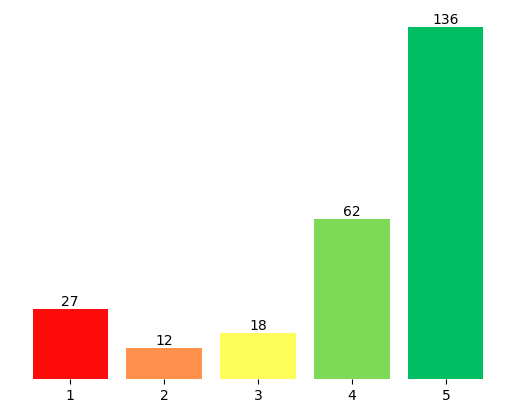

In [ ]:
# Define color mapping
color_mapping = {
    5: '#00bf63',
    4: '#7ed957',
    3: '#fffd59',
    2: '#ff914d',
    1: '#fd0a0a'
}

# Get value counts for each numeric rating
rating_counts = huawei_df['numeric_rating'].value_counts().sort_index()

# Map colors to the numeric ratings
colors = [color_mapping.get(x, '#999999') for x in rating_counts.index]

# Create bar plot
bars = plt.bar(x=rating_counts.index, height=rating_counts, color=colors)

# Add value counts as annotations on top of the bars
for bar, count in zip(bars, rating_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, str(count), ha='center', va='bottom')

plt.yticks([])

# Remove boundary around the chart
plt.box(False)

# Show the plot
plt.show()

### Correlation Between Ratings and Positive sentiment score

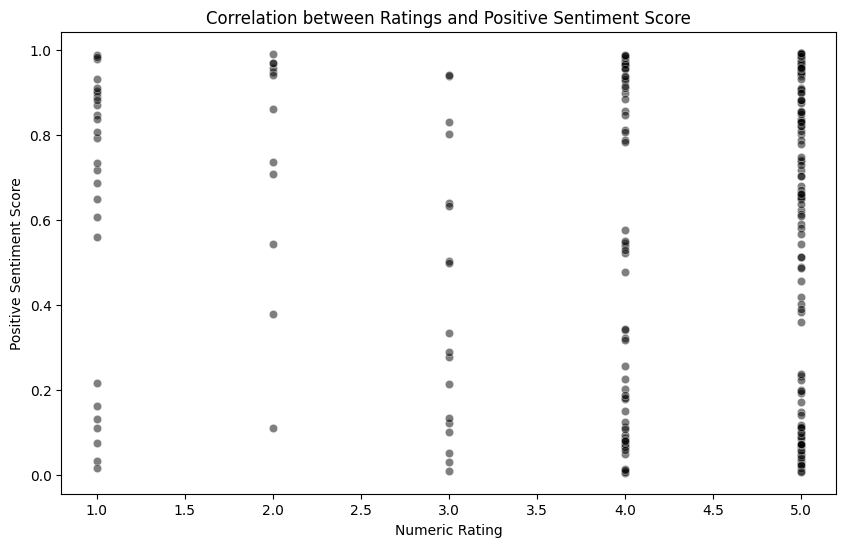

In [ ]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='numeric_rating', y='roberta_pos', data=huawei_df, color='black', alpha=0.5)

# Set labels and title
plt.xlabel('Numeric Rating')
plt.ylabel('Positive Sentiment Score')
plt.title('Correlation between Ratings and Positive Sentiment Score')

# Show the plot
plt.show()


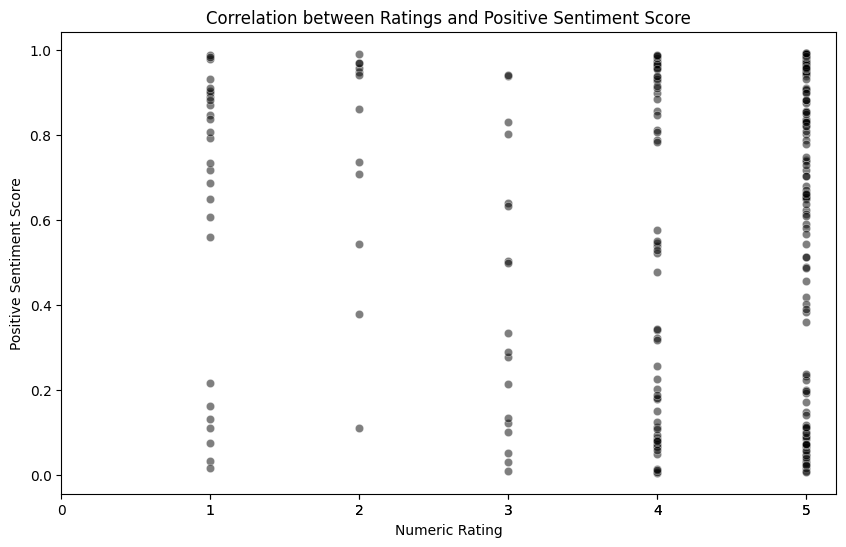

In [ ]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='numeric_rating', y='roberta_pos', data=huawei_df, color='black', alpha=0.5)

# Set x-axis ticks to integers
plt.xticks(list(map(int, plt.xticks()[0])))

# Set labels and title
plt.xlabel('Numeric Rating')
plt.ylabel('Positive Sentiment Score')
plt.title('Correlation between Ratings and Positive Sentiment Score')

# Show the plot
plt.show()


### Calculating Customer Satisfaction Score

In [ ]:
high_ratings_df = huawei_df[huawei_df['numeric_rating'].isin([4, 5])]

# Calculate the percentage of total responses
total_responses = len(huawei_df)
csat_score = len(high_ratings_df) / total_responses * 100

print(f"Customer Satisfaction Score (CSAT): {csat_score:.2f}%")

Customer Satisfaction Score (CSAT): 77.65%


### Customer Satisfaction Score by Title

In [ ]:
# Filter rows with numeric ratings of 4 and 5
high_ratings_df = apple_df[apple_df['numeric_rating'].isin([4, 5])]

# Calculate the percentage of high ratings grouped by title
grouped_df = high_ratings_df.groupby('title').size().reset_index(name='high_ratings_count')
grouped_df['total_responses'] = apple_df.groupby('title').size().reset_index(name='total_responses')['total_responses']
grouped_df['high_ratings_percentage'] = (grouped_df['high_ratings_count'] / grouped_df['total_responses']) * 100

# Print out the title and CSAT score
for index, row in grouped_df.iterrows():
    print(f"Title: {row['title']}, CSAT Score: {row['high_ratings_percentage']}%")

Title: iPad Mini 4 16gb Space Gray (Renewed), CSAT Score: 60.0%
Title: iPad Mini 4, 64GB with Retina Display, Wi, CSAT Score: 80.0%
Title: iPad mini 4 (32GB, Wi, CSAT Score: 60.0%
Title: iPhone X, 256GB, Space Gray, CSAT Score: 90.0%
Title: iPhone XR, 64GB, Black, CSAT Score: 90.0%
Title: iPhone XR, 64GB, Red, CSAT Score: 90.0%
Title: iPhone XS Max, 256GB, Gold, CSAT Score: 90.0%
Title: iPhone XS Max, 64GB, Gold, CSAT Score: 90.0%
Title: iPhone XS, 512GB, Gold, CSAT Score: 100.0%
Title: iPhone XS, 64GB, Gold, CSAT Score: 90.0%


### Categorizing the reviews

We exported the dataframe and mapped it manually to a category using Google sheets. This is output below.

In [ ]:
reviews = pd.read_csv('reviews.csv')
reviews

,asin,brand,title,rating,reviewUrl,review,rating_text,numeric_rating,neg,neu,...,roberta_neu,roberta_pos,roberta_neg.1,roberta_neu.1,roberta_pos.1,max_rating,csat,sentiment,Category,Problem
0,B0744W8WB2,Apple,Apple iPad Mini 4 16gb Space Gray (Renewed),3.8,https://www.amazon.com/product-reviews/B0744W8WB2,I was pleased with the product but surprised a...,5.0 out of 5 stars,5,0.000,0.798,...,0.813081,0.109847,0.077072,0.813081,0.109847,5,1.0,positive,Satisfied in general,NaN
1,B0744W8WB2,Apple,Apple iPad Mini 4 16gb Space Gray (Renewed),3.8,https://www.amazon.com/product-reviews/B0744W8WB2,"Para lo que yo necesito, me ha servidor mucho.",1.0 out of 5 stars,1,0.000,0.769,...,0.145850,0.825103,0.029047,0.145850,0.825103,5,0.2,positive,Satisfied in general,NaN
2,B0744W8WB2,Apple,Apple iPad Mini 4 16gb Space Gray (Renewed),3.8,https://www.amazon.com/product-reviews/B0744W8WB2,"The product I got works great, had a screen pr...",5.0 out of 5 stars,5,0.073,0.778,...,0.081722,0.902701,0.015577,0.081722,0.902701,5,1.0,positive,Functionality Concerns,Finger print reader
3,B0744W8WB2,Apple,Apple iPad Mini 4 16gb Space Gray (Renewed),3.8,https://www.amazon.com/product-reviews/B0744W8WB2,Great price for kid use. I bought two iPad min...,4.0 out of 5 stars,4,0.201,0.694,...,0.391894,0.322712,0.285394,0.391894,0.322712,5,0.8,negative,Great service,Battery
4,B0744W8WB2,Apple,Apple iPad Mini 4 16gb Space Gray (Renewed),3.8,https://www.amazon.com/product-reviews/B0744W8WB2,I purchased 2 mini iPads and were totally sati...,4.0 out of 5 stars,4,0.047,0.837,...,0.316792,0.071731,0.611476,0.316792,0.071731,5,0.8,positive,Functionality Concerns,Speaker
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,B07SWR8QZL,Apple,"Apple iPad Mini 4, 64GB with Retina Display, W...",4.1,https://www.amazon.com/product-reviews/B07SWR8QZL,iPad mini 4 came fairly fast and almost mint c...,5.0 out of 5 stars,5,0.045,0.808,...,0.100179,0.892960,0.006862,0.100179,0.892960,5,1.0,positive,Great service,Charger/Port
88,B07SWR8QZL,Apple,"Apple iPad Mini 4, 64GB with Retina Display, W...",4.1,https://www.amazon.com/product-reviews/B07SWR8QZL,I needed an iPad mini with cellular (or a larg...,2.0 out of 5 stars,2,0.000,0.802,...,0.069018,0.915660,0.015322,0.069018,0.915660,5,0.4,positive,Great appearance and condition,NaN
89,B07SWR8QZL,Apple,"Apple iPad Mini 4, 64GB with Retina Display, W...",4.1,https://www.amazon.com/product-reviews/B07SWR8QZL,I use my iPad 4mini for just about everything....,5.0 out of 5 stars,5,0.000,0.827,...,0.289633,0.564402,0.145965,0.289633,0.564402,5,1.0,positive,Functionality Concerns,NaN
90,B07WFJ6HRF,Apple,"Apple iPhone XS, 512GB, Gold - For Verizon (Re...",3.7,https://www.amazon.com/product-reviews/B07WFJ6HRF,Not verizon models,4.0 out of 5 stars,4,0.000,1.000,...,0.332698,0.466021,0.201281,0.332698,0.466021,5,0.8,neutral,Others,NaN


In [ ]:
reviews['Category'].unique()

array(['Satisfied in general', 'Functionality Concerns', 'Great service',
       'Others', 'Value for Money', 'Great appearance and condition',
       'Screen and display issues', nan], dtype=object)

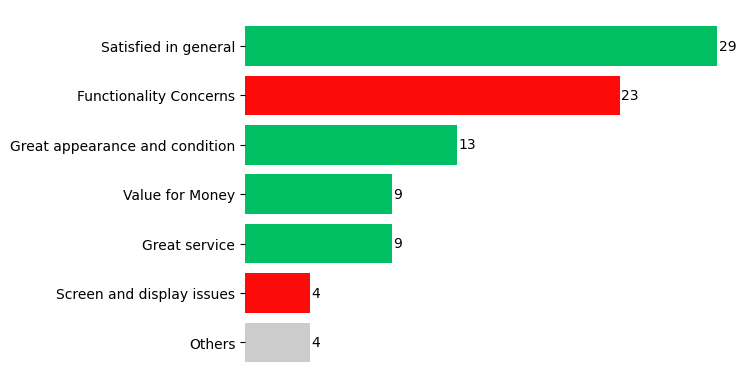

In [ ]:
# Define color mapping
color_mapping = {
    'Satisfied in general': '#00bf63',
    'Great service': '#00bf63',
    'Value for Money': '#00bf63',
    'Great appearance and condition': '#00bf63',
    'Others': '#cccccc',
    'Functionality Concerns': '#fd0a0a',
    'Screen and display issues': '#fd0a0a'
}

# Get value counts for each category
categories_count = reviews['Category'].value_counts().sort_values()

# Map colors to the categories
colors = [color_mapping.get(x, '#999999') for x in categories_count.index]

# Create horizontal bar plot
bars = plt.barh(y=categories_count.index, width=categories_count, color=colors)

# Add value counts as annotations on the right of the bars
for bar, count in zip(bars, categories_count):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, str(count), ha='left', va='center')

# Removing x-axis scale
plt.xticks([])

# Show the y-axis
plt.yticks(categories_count.index)

# Remove boundary around the chart
plt.box(False)

# Show the plot
plt.show()

### What Should We Focus on To Resolve the Issues?

In [ ]:
# Filter rows with non-NaN values in the "Problem" column
filtered_df = review_mapping.dropna(subset=['Problem'])

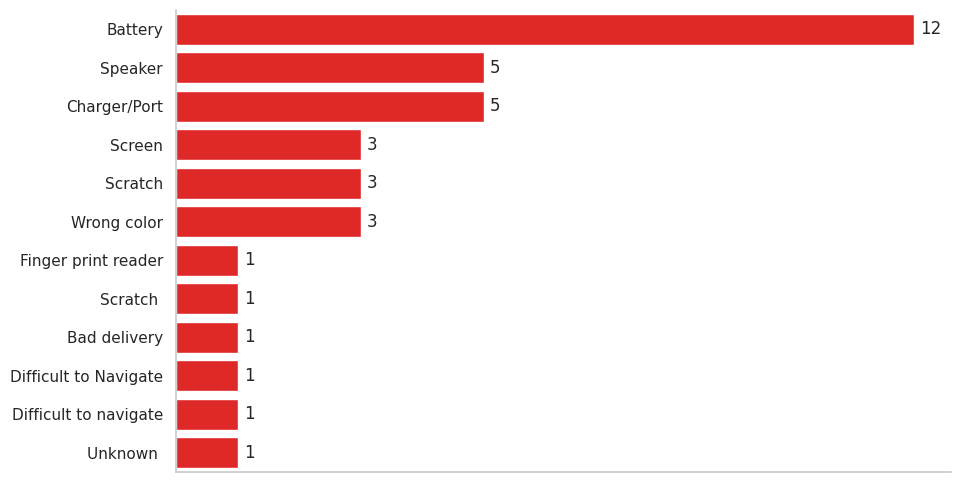

In [ ]:
# Get value counts for each problem category
problem_counts = filtered_df['Problem'].value_counts()

# Set the color for all bars
bar_color = '#fd0a0a'

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="Reds_r")  # Set palette to red

# Plot the horizontal bar chart with the specified color
bars = sns.barplot(x=problem_counts.values, y=problem_counts.index, color=bar_color)

# Adding value counts as annotations on the right side of the bars
for bar, count in zip(bars.patches, problem_counts):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, str(count), ha='left', va='center')

# Remove x-axis label
plt.xticks([])

# Remove the top and right spines for aesthetics
sns.despine(top=True, right=True)

# Show the plot
plt.show()

In [ ]:
pip install pandas textblob nltk networkx

In [ ]:
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.cluster.util import cosine_distance
import networkx as nx

In [ ]:
pip install vaderSentiment

In [ ]:
pip install bert-extractive-summarizer

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from summarizer import Summarizer

In [ ]:
import nltk
nltk.download('vader_lexicon')

In [ ]:
sid = SentimentIntensityAnalyzer()
apple_df['compound'] = apple_df['review'].apply(lambda x: sid.polarity_scores(x)['compound'])
apple_df['sentiment'] = apple_df['compound'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral'))

In [ ]:
# Text Summarization using TextBlob
def summarize_text(text, ratio=0.2):
    summarizer = Summarizer()
    summary = summarizer(text, ratio=ratio)
    return str(summary)

In [ ]:
# Create a context column based on sentiment
apple_df['context'] = ''
processed_rows = 0

for index, row in apple_df.iterrows():
    if row['sentiment'] == 'positive':
        apple_df.at[index, 'context'] = summarize_text(row['review'], ratio=0.1)
    processed_rows += 1

    # Print progress every 100 rows
    if processed_rows % 10 == 0:
        print(f"Processed {processed_rows} rows out of {len(apple_df)}.")

In [ ]:
apple_df['review'].tolist()

In [ ]:
huawei_df.to_csv("huawei_df.csv")

In [ ]:
# Display the dataframe with the new 'context' column
print(apple_df[['review', 'sentiment', 'context']])